# Arsenal Eras - Analysis & Expected-Points Model
### 2003/04 "Invincibles" vs 2025/26 champions

**Question:** *Two Arsenal title teams, 22 years apart - which one had the harder job?*

This notebook is the **data + modelling layer** behind the dashboard. It loads the raw
shot data for both seasons, cleans and aggregates it with **pandas**, fits an
**expected-points model** with **scikit-learn**, and exports the clean JSON the web app
consumes.

**Data sources**
- **2003/04** - [StatsBomb Open Data](https://github.com/statsbomb/open-data)
  (Premier League, `competition_id=2`, `season_id=44`). Shot-level events with
  StatsBomb's `statsbomb_xg`.
- **2025/26** - [Understat](https://understat.com) per-match xG (`datesData`) and
  per-player aggregates (`playersData`).

**Intellectual-honesty rule (carried into the app):** every output is tagged
**fact**, **measured**, or **speculative**, and the three are never blended. This
notebook produces the *measured* core (the expected-points model) and the inputs to
the *fact* / *speculative* sections.

In [1]:
# Make the local `analysis` package importable and pull in the scientific stack.
import sys, json
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import PoissonRegressor

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
GOLD, RED = "#c8971f", "#ef0107"
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.1.3


## 1. Load the raw data into a single canonical schema

The `analysis.loaders` module hides the messy per-source parsing (StatsBomb event JSON
vs Understat's embedded JS globals) behind two functions that return the **same**
per-match schema. That's the join that makes the two eras comparable.

In [2]:
from analysis import loaders

m0304 = loaders.load_statsbomb_matches()   # 38 rows from cached StatsBomb events
m2526 = loaders.load_understat_matches()   # 38 rows from cached Understat datesData
matches = pd.concat([m0304, m2526], ignore_index=True)

print("Combined per-match frame:", matches.shape)
matches.groupby("season").head(2)

Combined per-match frame: (76, 11)


,season,match_no,date,opponent,venue,gf,ga,result,points,xgf,xga
0,2003/04,1,2003-08-16,Everton,H,2,1,W,3,2.121,1.268
1,2003/04,2,2003-08-24,Middlesbrough,A,4,0,W,3,2.764,0.375
38,2025/26,1,2025-08-17,Manchester United,A,1,0,W,3,1.330,1.377
39,2025/26,2,2025-08-23,Leeds United,H,5,0,W,3,2.738,0.157


In [3]:
# Real dataframe hygiene: dtypes, null check, and the columns I'll model on.
matches.info()
print("\nNulls per column:\n", matches[["xgf", "xga", "gf", "ga"]].isna().sum().to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   season    76 non-null     object 
 1   match_no  76 non-null     int64  
 2   date      76 non-null     object 
 3   opponent  76 non-null     object 
 4   venue     76 non-null     object 
 5   gf        76 non-null     int64  
 6   ga        76 non-null     int64  
 7   result    76 non-null     object 
 8   points    76 non-null     int64  
 9   xgf       76 non-null     float64
 10  xga       76 non-null     float64
dtypes: float64(2), int64(4), object(5)
memory usage: 6.7+ KB

Nulls per column:
 xgf    0
xga    0
gf     0
ga     0


## 2. Aggregate with pandas (groupby)

Collapse 38 rows per season into the headline numbers that open the story.

In [4]:
from analysis import transforms

summary = transforms.all_season_summaries(matches)
summary[["season","points","wins","draws","losses","goals_for","goals_against",
         "xg_for","xg_against","ppg"]]

,season,points,wins,draws,losses,goals_for,goals_against,xg_for,xg_against,ppg
0,2003/04,90,26,12,0,73,26,60.870,30.880,2.368
1,2025/26,85,26,7,5,71,27,77.490,33.130,2.237


Note the contrast already visible in the aggregates:
- **2003/04** scored **more goals than its xG** (clinical finishing) and never lost.
- **2025/26** actually **under-scored its xG** but conceded fewer than expected - a
  title built on control and defence.

## 3. Rolling form (rolling window) + the title race

A trailing rolling mean of xG shows *momentum*; the cumulative-points curve is the
"title race" chart in the app.

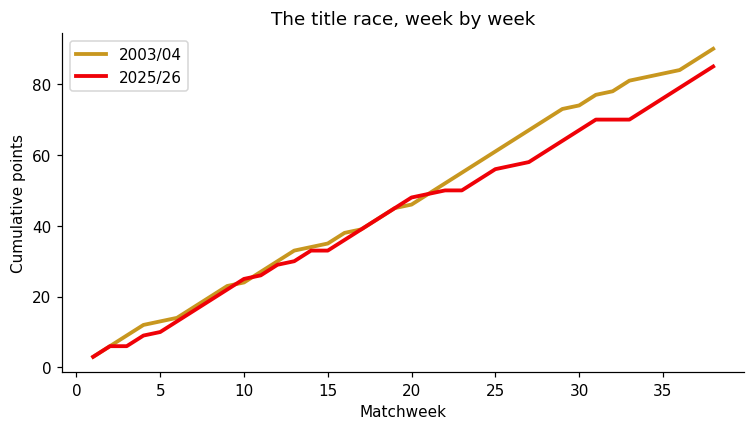

In [5]:
roll = transforms.add_rolling_form(matches, n=6)

fig, ax = plt.subplots(figsize=(8, 4))
for season, color in [("2003/04", GOLD), ("2025/26", RED)]:
    d = roll[roll.season == season].sort_values("match_no")
    ax.plot(d.match_no, d.cum_points, color=color, lw=2.5, label=season)
ax.set_xlabel("Matchweek"); ax.set_ylabel("Cumulative points")
ax.set_title("The title race, week by week"); ax.legend()
plt.show()

### 3a. A couple of exploratory views (seaborn + altair)

Two quick EDA cuts using the rest of the PyData viz stack - `seaborn` for a
statistical categorical view, `altair` for a declarative faceted one.

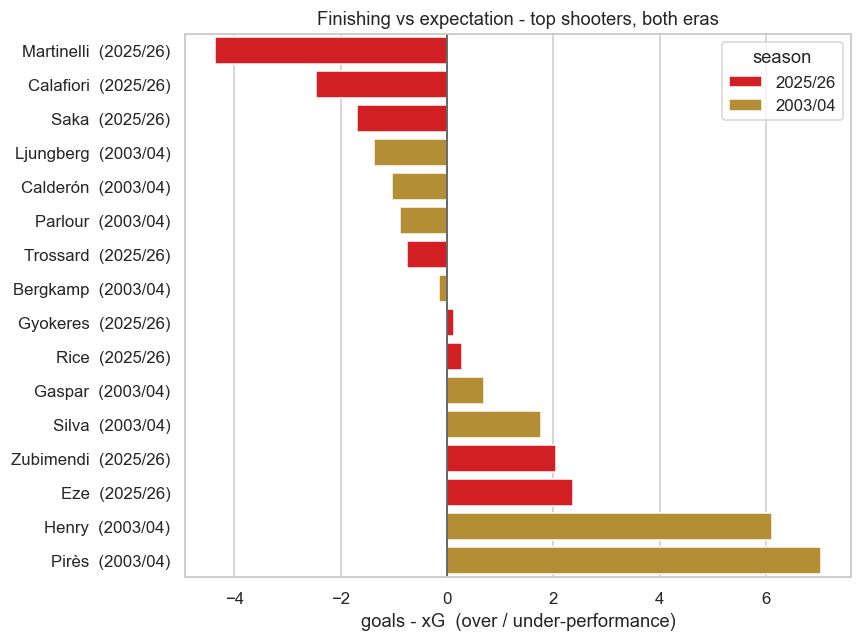

In [6]:
import seaborn as sns
sns.set_theme(style="whitegrid")

# Player-level finishing: goals minus xG, top shooters across both seasons.
players = pd.concat([loaders.load_statsbomb_players(),
                     loaders.load_understat_players()], ignore_index=True)
pt = transforms.player_table(players)
top = pt.sort_values("shots", ascending=False).groupby("season").head(8).copy()
top["label"] = top.player.str.split().str[-1] + "  (" + top.season + ")"

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top.sort_values("goals_minus_xg"), y="label", x="goals_minus_xg",
            hue="season", palette={"2003/04": GOLD, "2025/26": RED}, dodge=False, ax=ax)
ax.axvline(0, color="#444", lw=1)
ax.set_xlabel("goals - xG  (over / under-performance)"); ax.set_ylabel("")
ax.set_title("Finishing vs expectation - top shooters, both eras")
plt.tight_layout(); plt.show()

/Users/emerson/Desktop/Emerson Personal/Personal Coding/arsenal-research-engineer/.venv/lib/python3.12/site-packages/altair/utils/data.py:71: UserWarning: You passed a `narwhals.stable.v1.DataFrame` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(frame)`, did you mean `is_pandas_dataframe(frame.to_native())`?
  return _is_pandas_dataframe(obj) or isinstance(


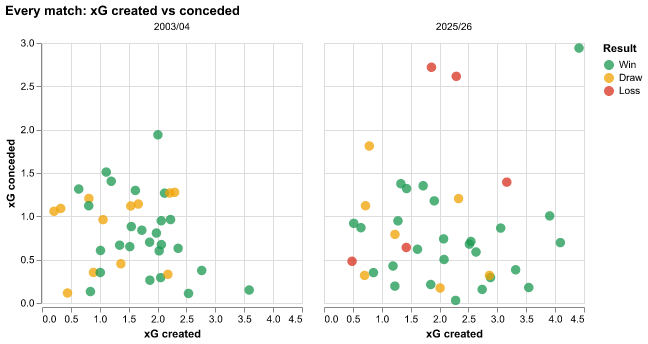

In [7]:
import altair as alt, io
from IPython.display import Image, display

# Declarative, faceted per-match view: xG created vs conceded, by result.
md_df = matches.assign(
    outcome=matches.result.map({"W": "Win", "D": "Draw", "L": "Loss"}),
    score=matches.gf.astype(str) + "-" + matches.ga.astype(str),
)
chart = (
    alt.Chart(md_df)
    .mark_circle(size=90, opacity=0.75)
    .encode(
        x=alt.X("xgf:Q", title="xG created"),
        y=alt.Y("xga:Q", title="xG conceded"),
        color=alt.Color("outcome:N",
                        scale=alt.Scale(domain=["Win", "Draw", "Loss"],
                                        range=["#1a9850", "#f0a202", "#d7301f"]),
                        title="Result"),
        tooltip=["opponent:N", "score:N", "xgf:Q", "xga:Q"],
    )
    .properties(width=260, height=260)
    .facet(column=alt.Column("season:N", title=None))
    .properties(title="Every match: xG created vs conceded")
)
# Rasterise via vl-convert so the chart stays visible outside a live kernel too.
buf = io.BytesIO(); chart.save(buf, format="png"); display(Image(buf.getvalue()))

## 4. The expected-points model (scikit-learn `PoissonRegressor`)

**Why Poisson-from-xG?** Goals are low-count, roughly independent events per team per
match - a textbook Poisson process - and xG already estimates the *mean* goals a team
should score, which maps onto the Poisson rate λ.

Rather than assume `goals == xG`, I fit a Poisson GLM of **actual goals on xG**, so the
model *calibrates* the xG→goals mapping. I fit on both perspectives of every match
(goals-scored vs xG-for, goals-conceded vs xG-against) → 2×38 = 76 observations per
season, and fit **separately per season** because the two xG providers differ.

In [8]:
from analysis import model

def fit_and_report(df, name):
    xg = np.concatenate([df.xgf.values, df.xga.values]).reshape(-1, 1)
    goals = np.concatenate([df.gf.values, df.ga.values])
    reg = PoissonRegressor(alpha=1e-6, max_iter=500).fit(xg, goals)
    pred = reg.predict(xg)
    print(f"{name}:  lambda = exp({reg.intercept_:+.3f} {reg.coef_[0]:+.3f}*xG)"
          f"   |  predicted goals {pred.sum():.1f}  vs actual {goals.sum()}")
    return reg, xg, goals

reg_0304, xg0, g0 = fit_and_report(m0304, "2003/04")
reg_2526, xg1, g1 = fit_and_report(m2526, "2025/26")

2003/04:  lambda = exp(-0.792 +0.744*xG)   |  predicted goals 99.0  vs actual 99
2025/26:  lambda = exp(-0.579 +0.475*xG)   |  predicted goals 98.0  vs actual 98


### 4a. Validation / sanity check

Two checks: (1) the fitted mean should be **calibrated** - total predicted goals ≈ total
actual goals (above, they match). (2) The fit should be monotone and sensible against
the raw scatter of xG vs goals.

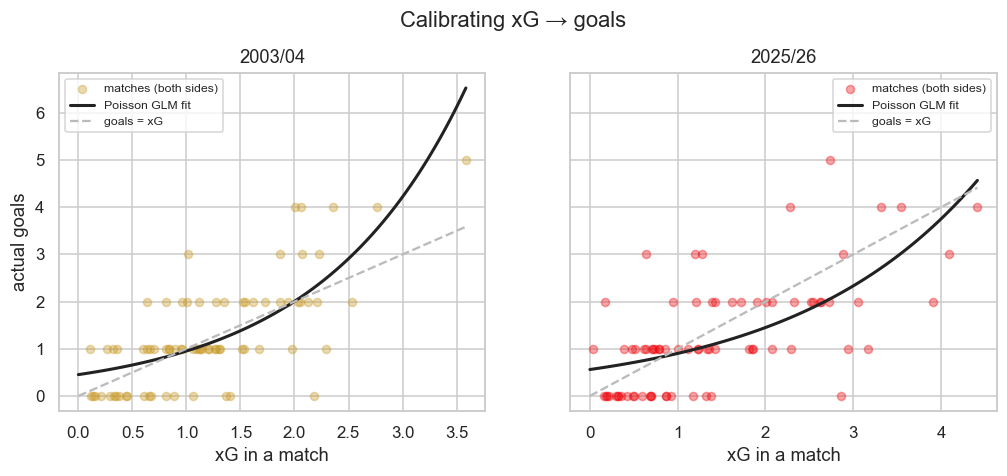

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (reg, xg, g, name, c) in zip(axes, [
        (reg_0304, xg0, g0, "2003/04", GOLD),
        (reg_2526, xg1, g1, "2025/26", RED)]):
    ax.scatter(xg.ravel(), g, alpha=0.35, color=c, s=28, label="matches (both sides)")
    grid = np.linspace(0, xg.max(), 100).reshape(-1, 1)
    ax.plot(grid, reg.predict(grid), color="#222", lw=2, label="Poisson GLM fit")
    ax.plot([0, xg.max()], [0, xg.max()], ls="--", color="#bbb", label="goals = xG")
    ax.set_title(name); ax.set_xlabel("xG in a match"); ax.legend(fontsize=8)
axes[0].set_ylabel("actual goals")
plt.suptitle("Calibrating xG → goals", y=1.02); plt.show()

### 4b. From rates to expected points

Given calibrated rates λ_for and λ_against, treat the two scorelines as independent
Poisson variables, sum the outcome probabilities into **expected points**
(`3·P(win) + 1·P(draw)`), and total over the season.

In [10]:
res_0304 = model.season_model_result(m0304)
res_2526 = model.season_model_result(m2526)

compare = pd.DataFrame([
    {"season": r["season"], "actual_points": r["actual_points"],
     "expected_points": r["expected_points"], "over_performance": r["points_over_expected"]}
    for r in (res_0304, res_2526)
])
compare

,season,actual_points,expected_points,over_performance
0,2003/04,90,69.400,20.600
1,2025/26,85,69.200,15.800


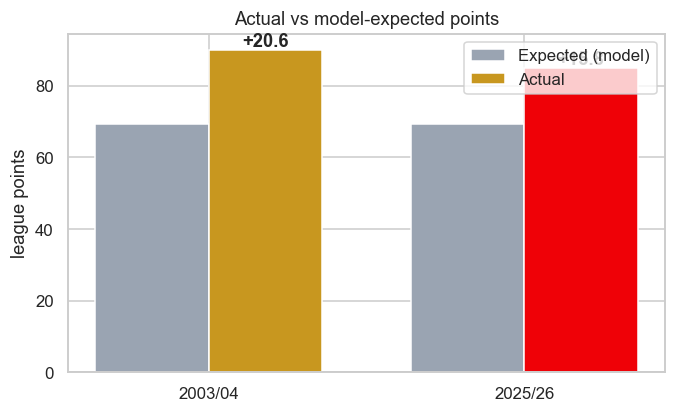

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2); w = 0.36
ax.bar(x - w/2, compare.expected_points, w, color="#9aa4b2", label="Expected (model)")
ax.bar(x + w/2, compare.actual_points, w, color=[GOLD, RED], label="Actual")
ax.set_xticks(x); ax.set_xticklabels(compare.season)
ax.set_ylabel("league points"); ax.set_title("Actual vs model-expected points")
ax.legend()
for i, r in compare.iterrows():
    ax.text(i + w/2, r.actual_points + 1, f"+{r.over_performance}", ha="center", fontweight="bold")
plt.show()

**Result:** both champions beat their expected points - the signature of a title team
that wins the tight games the model calls coin-flips. 2003/04 over-performed by more,
and did it by *out-finishing* its chances; 2025/26 did it by *out-defending* and holding
its nerve.

*Stated assumption:* the two teams' goal counts in a match are modelled as independent -
a known simplification (real scorelines are mildly correlated).

## 5. Era context (fact) & the thought experiment (speculative)

These feed Acts 3-4 of the story. Kept deliberately separate from the measured model
above. `schedule_difficulty` is derived from real results; the thought experiment is an
explicit, assumption-driven **range** - never a single number.

In [12]:
from analysis import era, facts

# Measured: points-per-game by opponent strength.
for season, df in [("2003/04", m0304), ("2025/26", m2526)]:
    sd = transforms.schedule_difficulty(df, facts.bottom_half_teams(season), facts.top_teams(season))
    print(f"{season}: {sd['ppg_vs_bottom_half']} PPG vs bottom half | "
          f"{sd['ppg_vs_top_rivals']} PPG vs top rivals")

# Speculative: transpose the Invincibles' 90 pts into 2025/26 conditions (a range).
te = era.thought_experiment_spec(base_points=int(m0304.points.sum()))
print("\nThought experiment (default VAR assumption):", te["default"]["range"], "pts")

2003/04: 2.5 PPG vs bottom half | 2.4 PPG vs top rivals
2025/26: 2.8 PPG vs bottom half | 1.1 PPG vs top rivals

Thought experiment (default VAR assumption): {'low': 82.0, 'high': 88.0} pts


## 6. Export the processed JSON

The single `build.run()` reproduces every file the API and frontend read
(`data/processed/*.json`, plus a baked copy in `web/public/data/`).

In [13]:
from analysis import build
result = build.run()
print("Wrote:", ", ".join(result["written"]))
print("Model summary:", result["model"])

Wrote: seasons.json, matches.json, players.json, model.json, era.json, thought_experiment.json, meta.json
Model summary: {'2003/04': (90, 69.4), '2025/26': (85, 69.2)}


---
### What I'd add with more time
- A **bivariate Poisson** (or Dixon-Coles adjustment) to drop the independence
  assumption and correct low-score correlation.
- **Cross-validation** of the GLM and a proper hold-out, rather than in-sample
  calibration only.
- **Uncertainty bands** on expected points by simulating each match from its λ.
- Player-level **physical data** and **defensive metrics** (both absent from open xG feeds).